# url4 Client — the requestor side

`Client` is the SDK entry point for **making queries**: build expressions in Python
(or write raw url4 text), run them locally or against a remote node, and get back a
`Url4Result` that always carries the exact canonical expression that ran.

Everything below runs **offline** against the notebook's demo fixture (`utils.demo`:
static documents + fake `/claude` / `/llama` model routes). The same calls work over
real HTTP by constructing `Client()` with no `io` — it then owns an httpx adapter —
or string-first: `Client("url4://host/v1")` targets a remote node directly. In plain
scripts (no event loop), `url4.evaluate_sync(expression, io)` is the one-call form.

In [1]:
from utils import demo, show_run

from url4 import Client, RenderError, Url, Url4Error, build, expr, render, src, text

client = Client(demo)  # inject any IOLayer; Client() would speak real HTTP

## Raw url4 text first

Strings are always first-class — `evaluate()` runs any url4 expression as-is.

In [2]:
res = await client.evaluate(
    "(article=https://news.example.com/ai-act, style='plain English')"
    "!'Summarize $article in $style'"
)
print(res.text)

Summarize EU lawmakers gave final approval to the AI Act, the first broad law governing artificial intelligence. It ranks systems by risk, bans social scoring and manipulative uses, and requires transparency and human oversight for high-risk uses in hiring, credit, and healthcare. Most rules phase in over two years. in plain English


## `Url4Result` — the result envelope

`.request` is the canonical expression that ran: log it, share it, re-run it —
the protocol's audit artifact (spec §1.2). `.json()` decodes a structured body;
`.elements` decodes the per-element collections that iteration and broadcast return.

In [3]:
print("request:", res.request)
print("text == str(res):", str(res)[:60], "…")

request: (article=https://news.example.com/ai-act, style='plain English')!'Summarize $article in $style'
text == str(res): Summarize EU lawmakers gave final approval to the AI Act, th …


## Building expressions in Python

Builders lower to the same AST the parser produces. `src()` keeps the spec's two
annotation axes visible: **attribution** (`name` / `weight` / `budgets`) and
**execution** (`mode` / `t` / `retry` / `required` / …). `render()` prints the
canonical text — and certifies it reparses to the identical tree.

In [4]:
e = expr(
    src(
        "https://news.example.com/ai-act",
        name="article",
        weight=0.9,
        budgets={"tokens": 4000},  # attribution axis
        t=30,
        required=True,
    ),  # execution axis
    src(text("plain English"), name="style"),
    intent="Summarize $article in $style",
)
print(render(e))
assert build(render(e)) == e  # render(check=True) certifies this on every call

(article:0.9:tokens=4000:https://news.example.com/ai-act;t=30;required, style='plain English')!'Summarize $article in $style'


In [5]:
res = await client.evaluate(e)
print(res.text)

Summarize EU lawmakers gave final approval to the AI Act, the first broad law governing artificial intelligence. It ranks systems by risk, bans social scoring and manipulative uses, and requires transparency and human oversight for high-risk uses in hiring, credit, and healthcare. Most rules phase in over two years. in plain English

EU lawmakers gave final approval to the AI Act, the first broad law governing artificial intelligence. It ranks systems by risk, bans social scoring and manipulative uses, and requires transparency and human oversight for high-risk uses in hiring, credit, and healthcare. Most rules phase in over two years.


## `query()` — the core call

Sources may be builder nodes or raw descriptor strings (they run through the full
grammar). Here: a weighted two-model ensemble whose intent merges the fan-out.

In [6]:
res = await client.query(
    "claude:0.6:/claude(https://news.example.com/ai-act)!'Summarize'",
    "llama:0.4:/llama(https://news.example.com/ai-act)!'Summarize'",
    intent="Merge $claude and $llama",
)
print(res.request)
print()
print(res.text)

(claude:0.6:/claude(https://news.example.com/ai-act)!'Summarize', llama:0.4:/llama(https://news.example.com/ai-act)!'Summarize')!'Merge $claude and $llama'

[claude] Consensus: the sources broadly agree; key points reconciled.


## `broadcast()` — `(sources)!*intent`

The intent is applied to each source independently; `.elements` decodes the
per-source result collection (spec §6.1.4).

In [7]:
res = await client.broadcast(
    "https://news.example.com/ai-act",
    "https://news.example.com/eu-funding",
    intent="One-line headline",
)
res.elements

[{'source_position': 1,
  'source_name': None,
  'result': 'One-line headline\n\nEU lawmakers gave final approval to the AI Act, the first broad law governing artificial intelligence. It ranks systems by risk, bans social scoring and manipulative uses, and requires transparency and human oversight for high-risk uses in hiring, credit, and healthcare. Most rules phase in over two years.'},
 {'source_position': 2,
  'source_name': None,
  'result': "One-line headline\n\nThe European Commission unveiled a EUR 1.5 billion plan to boost homegrown AI, funding shared GPU 'AI factories' for startups and universities and grants tied to compliance with the new AI Act."}]

## `iterate()` — `collection*(body)!intent`

Evaluate the body once per element; `$item` binds each row (spec §5.3). A Python
list becomes an inline parenthesized collection (§5.3.11).

In [8]:
res = await client.iterate(
    "https://data.example.com/support-tickets",
    "/claude($item.question)!'Answer'",
)
res.elements

['[claude] Re: How do I reset my password? — follow the documented steps; escalate if needed.',
 '[claude] Re: Why was my card declined at checkout? — follow the documented steps; escalate if needed.',
 '[claude] Re: Can I export my data as CSV? — follow the documented steps; escalate if needed.']

In [9]:
res = await client.iterate(
    ["Attention Is All You Need", "The Bitter Lesson"],
    intent="Summarize the paper: $item",
    reduce="Aggregate the summaries into one reading guide",
)
print(res.request)
print()
print(res.text)

(('Attention Is All You Need', 'The Bitter Lesson')*()!'Summarize the paper: $item')!'Aggregate the summaries into one reading guide'

'Aggregate the summaries into one reading guide'

["Summarize the paper: Attention Is All You Need", "Summarize the paper: The Bitter Lesson"]


## `reduce()` — fan-out calls, then merge

Sugar for `query()` with expression sources: `(call1, call2)!intent`.

In [10]:
res = await client.reduce(
    "/claude(https://news.example.com/ai-act)!'Summarize'",
    "/llama(https://news.example.com/eu-funding)!'Summarize'",
    intent="Merge $1 and $2 into one paragraph",
)
print(res.text)

[claude] Consensus: the sources broadly agree; key points reconciled.


## Targeting a remote node

A `node=` target wraps the expression in a remote sub-request — the wire hop is
just another DAG node, and the **remote** node resolves the sources and runs the
intent (spec §5.6.3 pass-through). `.request` shows the exact remote URI form.
Over real HTTP the whole setup is one line: `Client("url4://analyst.example.ai")`.

In [11]:
from url4 import StaticIOLayer

analyst = StaticIOLayer(
    routes={
        "url4://analyst.example.ai/v1": lambda context, intent: (
            f"[analyst.example.ai] ran {intent!r} over {context!r}"
        )
    }
)
async with Client(analyst, node="url4://analyst.example.ai") as remote:
    res = await remote.query(
        src("https://news.example.com/ai-act", name="a"),
        intent="Deep analysis of $a",
    )
print(res.request)
print(res.text)

(url4://analyst.example.ai/v1(a=https://news.example.com/ai-act)!'Deep analysis of $a')
[analyst.example.ai] ran 'Deep analysis of $a' over 'a=https://news.example.com/ai-act'


## Scope seeding and protocol params

`env=` binds `$name` references; protocol params ride the expression — and the
executor **enforces** `quorum`.

In [12]:
res = await client.evaluate(
    "(https://news.example.com/ai-act)!'[$audience] Summarize $1'",
    env={"audience": "board briefing"},
)
print(res.text[:120])

[board briefing] Summarize EU lawmakers gave final approval to the AI Act, the first broad law governing artificial inte


In [13]:
res = await client.query("https://news.example.com/ai-act", intent="Summarize", quorum=1, t=60)
print(res.request)

try:  # quorum=2 with one source can never be met
    await client.query("https://news.example.com/ai-act", intent="Summarize", quorum=2)
except Url4Error as exc:
    print(f"{type(exc).__name__}({exc.code}): {exc}")

(https://news.example.com/ai-act)!'Summarize';quorum=1;t=60
ResolutionError(quorum_not_met): quorum not met: 1 of 2 required sources resolved


## Guardrails — no silently-wrong wire text

`render()` refuses values the grammar cannot carry (a bare URI with a structural
comma would split the source list on reparse).

In [14]:
try:
    render(Url("https://api.example.com/point?lat=1.0,lon=2.0"))
except RenderError as exc:
    print(f"RenderError: {exc}")

# carried as quoted text instead (a deliberate, visible choice):
print(
    render(
        expr(
            src(text("https://api.example.com/point?lat=1.0,lon=2.0"), name="u"),
            intent="Describe $u",
        )
    )
)

RenderError: URI 'https://api.example.com/point?lat=1.0,lon=2.0' cannot be carried bare: ',' at offset 37 is structural at depth 0 (quote-as-Text changes semantics)
(u='https://api.example.com/point?lat=1.0,lon=2.0')!'Describe $u'


## Seeing the execution

The house `show_run` helper renders the compiled DAG with real completion order —
useful when a query grows into a tree.

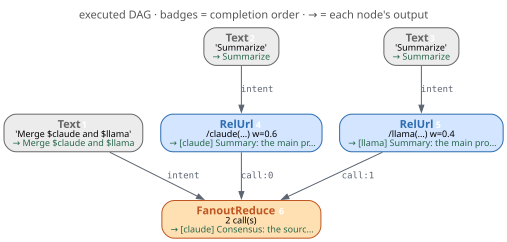

#,node,inputs,output
1,Text 'Merge $claude and $llama',—,Merge $claude and $llama
2,Text 'Summarize',—,Summarize
3,Text 'Summarize',—,Summarize
4,RelUrl /claude(…) w=0.6,intent=Summarize,"[claude] Summary: the main provisions, …"
5,RelUrl /llama(…) w=0.4,intent=Summarize,"[llama] Summary: the main provisions, o…"
6,FanoutReduce 2 call(s),"intent=Merge $claude and…, call:0=[claude] Summary:…, call:1=[llama] Summary: …",[claude] Consensus: the sources broadly…


In [15]:
await show_run(
    "(claude:0.6:/claude(https://news.example.com/ai-act)!'Summarize',"
    "llama:0.4:/llama(https://news.example.com/ai-act)!'Summarize')"
    "!'Merge $claude and $llama'",
    demo,
)

---
**Next:** `url4_server.ipynb` — stand up the node these queries talk to
(`Url4Node`: endpoints, holdings, identities, and HTTP serving).